In [1]:
!pip install yfinance

In [2]:
import yfinance as yf

stocks = ['BTC-USD', 'ETH-USD', 'DOGE-USD', 'MATIC-USD']

data = yf.download(stocks,
                  '2020-01-01',
                '2022-01-01')['Close']

[*********************100%***********************]  4 of 4 completed


In [3]:
data.head()

Ticker,BTC-USD,DOGE-USD,ETH-USD,MATIC-USD
Date,,,,
2020-01-01,7200.174316,0.002033,130.802002,0.014962
2020-01-02,6985.470215,0.002009,127.410179,0.014651
2020-01-03,7344.884277,0.002145,134.171707,0.015194
2020-01-04,7410.656738,0.002241,135.069366,0.014961
2020-01-05,7411.317383,0.002419,136.276779,0.014914


In [5]:
returns = data.pct_change()

returns.head()

Ticker,BTC-USD,DOGE-USD,ETH-USD,MATIC-USD
Date,,,,
2020-01-01,NaN,NaN,NaN,NaN
2020-01-02,-0.029819,-0.011805,-0.025931,-0.020786
2020-01-03,0.051452,0.067695,0.053069,0.037062
2020-01-04,0.008955,0.044755,0.006690,-0.015335
2020-01-05,0.000089,0.079429,0.008939,-0.003141


In [6]:
returns = returns.dropna()

returns.head()

Ticker,BTC-USD,DOGE-USD,ETH-USD,MATIC-USD
Date,,,,
2020-01-02,-0.029819,-0.011805,-0.025931,-0.020786
2020-01-03,0.051452,0.067695,0.053069,0.037062
2020-01-04,0.008955,0.044755,0.006690,-0.015335
2020-01-05,0.000089,0.079429,0.008939,-0.003141
2020-01-06,0.048291,0.018189,0.058905,0.045125


In [7]:
average_daily_returns = returns.mean()

print(average_daily_returns)

Ticker
BTC-USD      0.003378
DOGE-USD     0.012562
ETH-USD      0.006022
MATIC-USD    0.010726
dtype: float64


In [8]:
standard_deviation_daily_returns = returns.std()

print(standard_deviation_daily_returns)

Ticker
BTC-USD      0.039975
DOGE-USD     0.160617
ETH-USD      0.052792
MATIC-USD    0.088076
dtype: float64


In [9]:
import numpy

weights = numpy.array([0.3, 0.1, 0.5, 0.1])

In [10]:
covariance_matrix = (returns.cov()) * 250

print(covariance_matrix)

Ticker      BTC-USD  DOGE-USD   ETH-USD  MATIC-USD
Ticker                                            
BTC-USD    0.399490  0.474450  0.419504   0.482358
DOGE-USD   0.474450  6.449436  0.534732   0.505527
ETH-USD    0.419504  0.534732  0.696741   0.703413
MATIC-USD  0.482358  0.505527  0.703413   1.939334


In [11]:
expected_portfolio_performance = numpy.sum(average_daily_returns * weights)

print(expected_portfolio_performance)

0.006353474227349121


In [12]:
returns['Portfolio Returns'] = returns.dot(weights)

In [13]:
returns.head()

Ticker,BTC-USD,DOGE-USD,ETH-USD,MATIC-USD,Portfolio Returns
Date,,,,,
2020-01-02,-0.029819,-0.011805,-0.025931,-0.020786,-0.025170
2020-01-03,0.051452,0.067695,0.053069,0.037062,0.052446
2020-01-04,0.008955,0.044755,0.006690,-0.015335,0.008974
2020-01-05,0.000089,0.079429,0.008939,-0.003141,0.012125
2020-01-06,0.048291,0.018189,0.058905,0.045125,0.050271


In [14]:
daily_cumulative_returns = (1 + returns).cumprod()

print(daily_cumulative_returns)

Ticker       BTC-USD   DOGE-USD    ETH-USD   MATIC-USD  Portfolio Returns
Date                                                                     
2020-01-02  0.970181   0.988195   0.974069    0.979214           0.974830
2020-01-03  1.020098   1.055091   1.025762    1.015506           1.025955
2020-01-04  1.029233   1.102312   1.032625    0.999933           1.035162
2020-01-05  1.029325   1.189867   1.041855    0.996792           1.047713
2020-01-06  1.079032   1.211510   1.103226    1.041773           1.100383
...              ...        ...        ...         ...                ...
2021-12-27  7.033221  92.329063  30.867629  182.191825          45.183493
2021-12-28  6.609403  85.645346  29.058371  166.970053          42.337910
2021-12-29  6.450498  82.520904  27.740644  165.085284          40.870335
2021-12-30  6.552359  84.266106  28.392930  170.949804          41.776082
2021-12-31  6.431295  83.864236  28.154254  168.901686          41.298958

[730 rows x 5 columns]


In [15]:
daily_cumulative_returns.head()

Ticker,BTC-USD,DOGE-USD,ETH-USD,MATIC-USD,Portfolio Returns
Date,,,,,
2020-01-02,0.970181,0.988195,0.974069,0.979214,0.974830
2020-01-03,1.020098,1.055091,1.025762,1.015506,1.025955
2020-01-04,1.029233,1.102312,1.032625,0.999933,1.035162
2020-01-05,1.029325,1.189867,1.041855,0.996792,1.047713
2020-01-06,1.079032,1.211510,1.103226,1.041773,1.100383


In [17]:
daily_cumulative_returns.tail()

Ticker,BTC-USD,DOGE-USD,ETH-USD,MATIC-USD,Portfolio Returns
Date,,,,,
2021-12-27,7.033221,92.329063,30.867629,182.191825,45.183493
2021-12-28,6.609403,85.645346,29.058371,166.970053,42.337910
2021-12-29,6.450498,82.520904,27.740644,165.085284,40.870335
2021-12-30,6.552359,84.266106,28.392930,170.949804,41.776082
2021-12-31,6.431295,83.864236,28.154254,168.901686,41.298958


In [21]:
import matplotlib.pyplot as pyplot

pyplot.rcParams['figure.figsize'] = (20, 10)

pyplot.rcParams.update({'font.size' : 18})

<Axes: xlabel='Returns', ylabel='Distribution'>

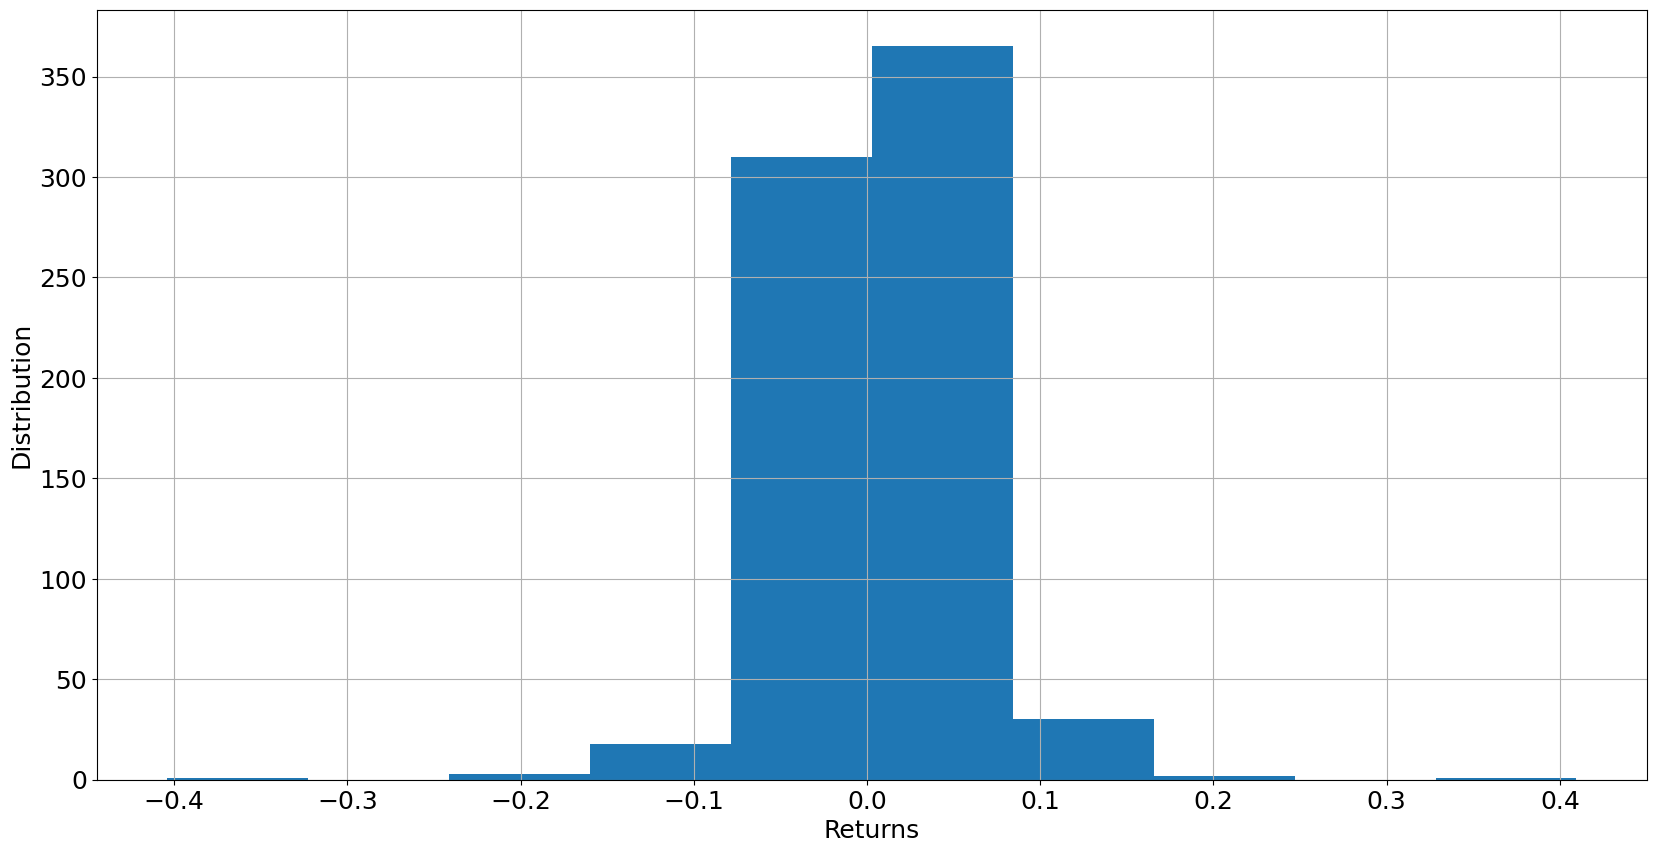

In [23]:
pyplot.ylabel('Distribution')

pyplot.xlabel('Returns')

returns['Portfolio Returns'].hist()

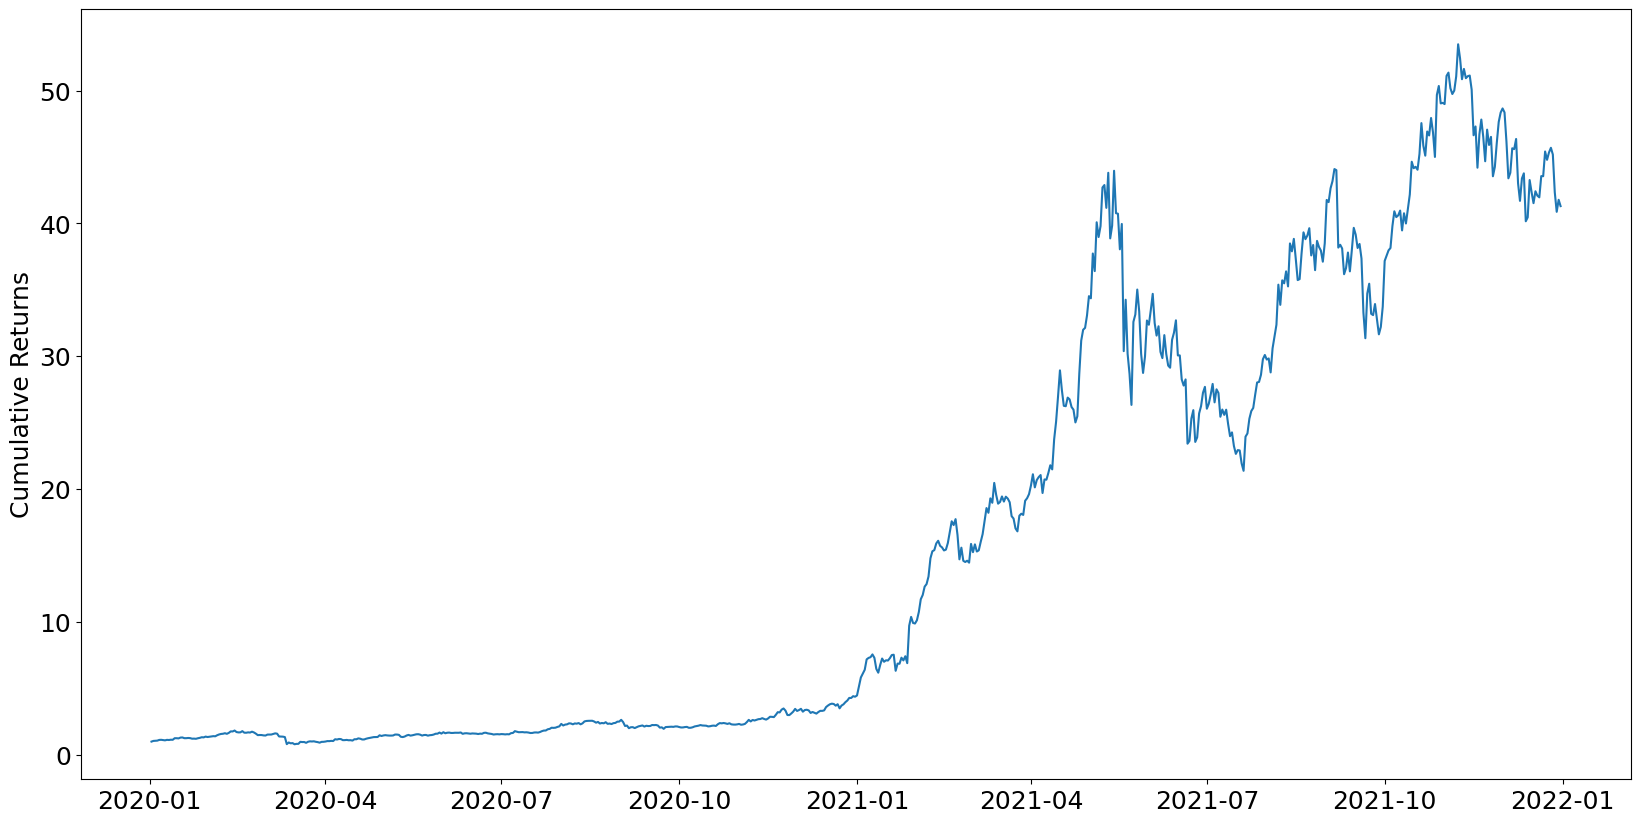

In [25]:
figure, axes = pyplot.subplots()

pyplot.ylabel('Cumulative Returns')

axes.plot(daily_cumulative_returns.index, daily_cumulative_returns['Portfolio Returns'])

In [26]:
average_returns = returns['Portfolio Returns'].mean()

print(average_returns)

0.00635347422734912


In [27]:
average_returns_percentage = average_returns * 100

print(average_returns_percentage)

0.635347422734912


In [28]:
standard_deviation_portfolio = returns['Portfolio Returns'].std()*100

print(standard_deviation_portfolio)

4.944538861492711


In [29]:
skewness = returns['Portfolio Returns'].skew()

print(skewness)

-0.09688381336207014


In [30]:
kurtosis = returns['Portfolio Returns'].kurtosis()

print(kurtosis)

13.859813217842404


In [31]:
difference = returns['Portfolio Returns'][-1] - returns['Portfolio Returns'][0]

total_returns = difference / returns['Portfolio Returns'][0]

print(total_returns)

-0.5462538792146122


C:\Users\David Moon\AppData\Local\Temp\ipykernel_7976\2933064383.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  difference = returns['Portfolio Returns'][-1] - returns['Portfolio Returns'][0]
C:\Users\David Moon\AppData\Local\Temp\ipykernel_7976\2933064383.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_returns = difference / returns['Portfolio Returns'][0]


In [32]:
import numpy

volatility = returns['Portfolio Returns'].std() * numpy.sqrt(250)

print(volatility)

0.7818002390766394


In [34]:
variance = numpy.dot(weights.T,  numpy.dot(covariance_matrix, weights))

print(variance)

0.6112116138202899


In [35]:
negative_returns = returns.loc[returns['Portfolio Returns'] < 0]

negative_returns.head()

Ticker,BTC-USD,DOGE-USD,ETH-USD,MATIC-USD,Portfolio Returns
Date,,,,,
2020-01-02,-0.029819,-0.011805,-0.025931,-0.020786,-0.025170
2020-01-08,-0.010269,-0.057542,-0.015924,-0.006225,-0.017420
2020-01-09,-0.024851,-0.016136,-0.016133,-0.020458,-0.019181
2020-01-11,-0.015798,-0.017827,-0.007201,-0.002491,-0.010372
2020-01-13,-0.005896,-0.009660,-0.011293,0.034779,-0.004903


In [36]:
expected_negative_returns = returns['Portfolio Returns'].mean()

print(expected_negative_returns)

0.00635347422734912


In [37]:
std_negative_returns = negative_returns.std()

print(std_negative_returns)

Ticker
BTC-USD              0.033516
DOGE-USD             0.064811
ETH-USD              0.041536
MATIC-USD            0.063013
Portfolio Returns    0.037975
dtype: float64


In [38]:
sortino_ratio = (expected_negative_returns - 0.01) / std_negative_returns

print(sortino_ratio)

Ticker
BTC-USD             -0.108800
DOGE-USD            -0.056264
ETH-USD             -0.087791
MATIC-USD           -0.057869
Portfolio Returns   -0.096024
dtype: float64


In [41]:
rolling_max = returns['Portfolio Returns'].rolling(center = False, min_periods = 1, window = 250).max()

print(rolling_max)

Date
2020-01-02   -0.025170
2020-01-03    0.052446
2020-01-04    0.052446
2020-01-05    0.052446
2020-01-06    0.052446
                ...   
2021-12-27    0.237431
2021-12-28    0.237431
2021-12-29    0.237431
2021-12-30    0.237431
2021-12-31    0.237431
Name: Portfolio Returns, Length: 730, dtype: float64


In [44]:
daily_drawdown = returns['Portfolio Returns'] / rolling_max -1

print(daily_drawdown)

Date
2020-01-02    0.000000
2020-01-03    0.000000
2020-01-04   -0.828896
2020-01-05   -0.768807
2020-01-06   -0.041461
                ...   
2021-12-27   -1.046834
2021-12-28   -1.265249
2021-12-29   -1.145993
2021-12-30   -0.906661
2021-12-31   -1.048102
Name: Portfolio Returns, Length: 730, dtype: float64


In [45]:
negative_daily_drawdown = daily_drawdown.rolling(center = False, min_periods = 1, window = 250).min()

print(negative_daily_drawdown)

Date
2020-01-02    0.000000
2020-01-03    0.000000
2020-01-04   -0.828896
2020-01-05   -0.828896
2020-01-06   -0.828896
                ...   
2021-12-27   -1.585357
2021-12-28   -1.585357
2021-12-29   -1.585357
2021-12-30   -1.585357
2021-12-31   -1.585357
Name: Portfolio Returns, Length: 730, dtype: float64


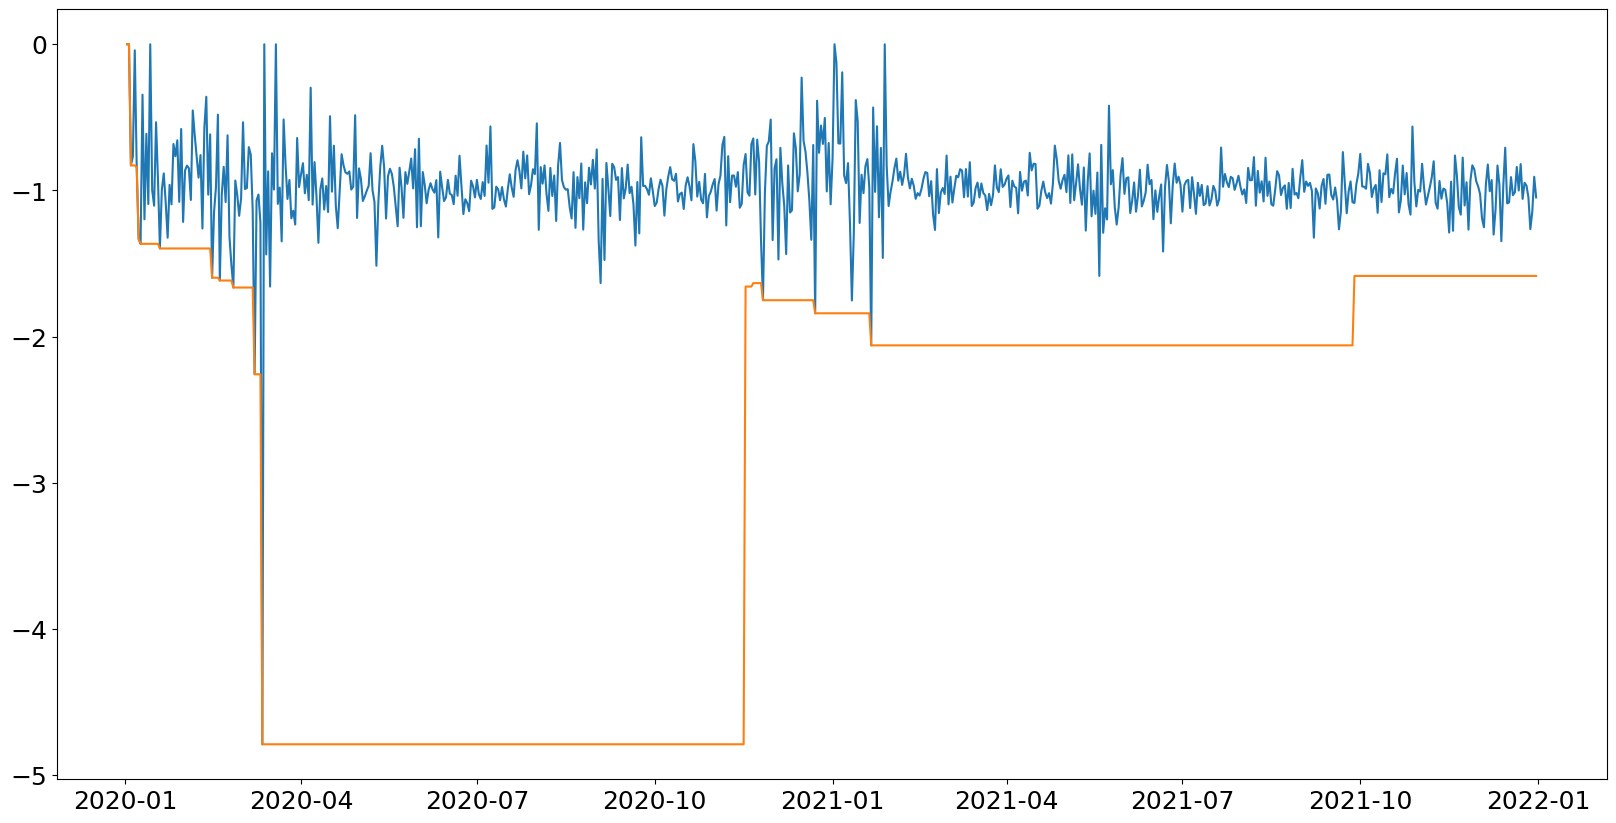

In [47]:
pyplot.plot(returns.index, daily_drawdown)

pyplot.plot(returns.index, negative_daily_drawdown)